In [1]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

In [2]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
from scipy.spatial.distance import cdist
import xarray as xr

import sys

sys.path.append("../../..")
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()


def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5 * (x - mu) ** 2 / sigma**2)
    return y / np.max(y)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

numexpr.utils — INFO — Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
numexpr.utils — INFO — NumExpr defaulting to 16 threads.
Constants — INFO — Logging to file: /home/jsb92/Documents/pyS3M/notebooks/figures/SI/../../../logs/Constants_20260629_153209.log


# Refactored Code Example Using New Interface

This section demonstrates how to run the same 3-camera comparison using the new refactored `test_simulation_method()` interface with proper parameter validation and configuration management.

In [3]:
# Import the new refactored classes
from src.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)

print("Imported new refactored classes successfully!")
print("Available fitting strategies:", [strategy.value for strategy in FittingStrategy])

Imported new refactored classes successfully!
Available fitting strategies: ['standard', 'standard_iter', 'standard_data', 'elliptical', 'demosaic', 'demosaic_fast', 'demosaic_ig', 'standard_ig']


In [4]:
# data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [5]:
image_size = 14
masks = M_F.get_masks(size_x=image_size, size_y=image_size, mosaic_unit=np.array([['G', 'G'], ['R', 'B']]))
R, G, B, wavelength = S_F.getpixelefficiency()

cameras = ["Camera_OddPattern"]

wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])

In [6]:
image_size = 10
masks = M_F.get_masks(size_x=image_size, size_y=image_size, mosaic_unit=np.array([['G', 'G'], ['R', 'B']]))
R, G, B, wavelength = S_F.getpixelefficiency()


camera_parameters_dict = {
    "gain": np.full((image_size, image_size), np.median(gain)),
    "offset": np.full((image_size, image_size), np.median(offset)),
    "variance": np.full((image_size, image_size), np.median(variance)),
    "readnoise": np.full((image_size, image_size), np.median(readnoise)),
    "rqe": np.full((image_size, image_size), np.median(rqe)),
    "masks": masks,
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": {
        "C": 0,
        "Y": 1,
        "M": 2,
    },  # Fixed to use dict instead of list
}


In [ ]:
dye = "Cy3B"
n_photons = {}
n_photon = 4000
n_photons[dye] = np.full(1, n_photon)
pixel_size = 69
dye_matrix = np.zeros([1, len(wavelength)])
filters = []
x0y0 = {}
max = pixel_size * image_size

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
NA = 1.49
x0 = 5 * pixel_size
y0 = 5 * pixel_size
for dye in n_photons:
    x0y0[dye] = np.zeros([1, 2, 1])
    x0y0[dye][:, :, :] = np.array([[y0, x0]]).T

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
n_background = 4
image_for_RGGB_647N, _, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)


In [ ]:
fig, axs = plotter.one_column_plot(height=1, width=1)

axs = plotter.image_plot(axs, image_for_RGGB_647N, colorbar='off', scalebarsize=200, pixelsize=69, scalebarlabel='200 nm')
#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/RGGB'
#plt.savefig(os.path.join(folder, 'RGGB_Cy3BImage.svg'), dpi=600, format='svg')
plt.show()

In [ ]:
# Create simulation configuration using the new dataclass
config_refactored = SimulationConfig(
    n_bootstrap=100000,  # Reduced for faster testing - increase to 100000 for full run
    background_photons=5.0,
    background_colour=[1, 1, 1],
    NA=1.49,
    pixel_size=69,
    cpu_fraction=0.9,
    save_raw_results=True,
    subtractx0y0=False,  # Important for position accuracy analysis
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
)

print("Simulation configuration created:")
print(f"  Bootstrap samples: {config_refactored.n_bootstrap}")
print(f"  Background photons: {config_refactored.background_photons}")
print(f"  Numerical aperture: {config_refactored.NA}")
print(f"  Pixel size: {config_refactored.pixel_size} nm")
print(f"  Save raw results: {config_refactored.save_raw_results}")
print(f"  Subtract ground truth positions: {config_refactored.subtractx0y0}")

In [ ]:
# Setup save folder for refactored results
save_folder_refactored = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260629_ArbitraryPixelPattern"
if not os.path.isdir(save_folder_refactored):
    os.makedirs(save_folder_refactored)

print(f"Results will be saved to: {save_folder_refactored}")

# Reduced photon space and dye list for testing
n_photon_space = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)
dyes = ["ATTO 488", "ATTO 520", "ATTO 565", "ATTO 594"]

notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
nilered_filter = "semrock-ff01-650-200-25"
shortpass_filter = "semrock-bsp01-785r"
filters = [dichroic_mirror, notch_filter]

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

print(f"Testing with photon levels: {n_photon_space}")
print(f"Testing with dyes: {dyes}")

In [ ]:
# Run simulations using the new refactored interface
print("Running simulations with new refactored interface...")
print("=" * 60)

for i, dye in enumerate(dyes):
    print(f"🔬 Analysing {dye}...")

    try:
        # Use the new unified method with STANDARD strategy (equivalent to old test_fit_method)
        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_parameters_dict,
            save_folder=save_folder_refactored,
            n_photon_space=n_photon_space,  # Using test range
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.STANDARD_DATA,  # smooth→model→data weights (validated default)
            starting_flag=f"arbitrary_pixel_pattern_",
            config=config_refactored,  # New config dataclass
            overwrite=True
        )
        print(f"✅ Completed {dye}")

    except Exception as e:
        print(f"❌ Failed {dye}: {str(e)}")

print("\\n🎉 Refactored simulations completed!")
print(f"📁 Check results in: {save_folder_refactored}")

In [ ]:
def euclidean_distance(ground_truth_points, fitted_points):
    """
    Calculates the minimum Euclidean distance from each fitted point to any ground truth point.

    This is appropriate for localization precision analysis where the number of
    fitted points may differ from the number of ground truth points.

    Args:
      ground_truth_points: A NumPy array of shape (n, 2) representing ground truth positions.
      fitted_points: A NumPy array of shape (m, 2) representing fitted positions.

    Returns:
      A NumPy array of shape (m,) containing the minimum distance from each fitted
      point to any ground truth point.
    """
    # Ensure both arrays are 2D
    ground_truth_points = np.atleast_2d(ground_truth_points)
    fitted_points = np.atleast_2d(fitted_points)

    # Calculate distance matrix and return minimum distance for each fitted point
    distance_matrix = np.linalg.norm(ground_truth_points - fitted_points, axis=1)
    return distance_matrix

In [ ]:
save_folder_refactored = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260311_ArbitraryPixelPattern"
all_files = np.sort(os.listdir(save_folder_refactored))
labels = ["Camera_OddPattern"]
parameters = ["xy", "colour"]
n_photon_space = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)

In [ ]:
Overall_XR = xr.DataArray(
    data=np.zeros([len(dyes), len(n_photon_space), len(parameters)]),
    coords=[dyes, n_photon_space, parameters],
    dims=["Dye", "Photon", "Analysis_Parameter"],
)
for j, dye in enumerate(dyes):
    dye_file = np.sort(
        [os.path.join(save_folder_refactored, x) for x in all_files if dye in x]
    )
    dye_file_raw = np.sort([x for x in dye_file if "rawresults" in x])
    dye_xy_gt = pd.read_csv(np.sort([x for x in dye_file if "groundtruth" in x])[0])
    dye_x0 = dye_xy_gt["x0"].to_numpy() / 69
    dye_y0 = dye_xy_gt["y0"].to_numpy() / 69
    x0y0 = np.vstack([dye_x0, dye_y0]).T
    dye_BGR = pd.read_csv(
        np.sort([x for x in dye_file if "input_parameters" in x])[0]
    ).to_numpy()[0][-3:]
    dye_BGR = dye_BGR / np.sum(dye_BGR)
    overall_results = pd.read_hdf(os.path.join(save_folder_refactored, dye_file_raw[0]))
    for k, photonval in enumerate(n_photon_space):
        results = overall_results[overall_results.photon_level == k]
        filt = ~(
            (results["xc"] < 0)
            | (results["yc"] < 0)
            | (results["s_x"] < 0)
            | (results["s_y"] < 0)
            | (results["xc"] > 14)
            | (results["yc"] > 14)
        )
        n_removed = (~filt).sum()
        if n_removed > 0:
            print(f"For {camera} at {photonval}, {n_removed} points were removed.")
        # Signed per-axis localisation errors (pixels)
        error_x = results["xc"].to_numpy()[filt] - x0y0[filt, 0]
        error_y = results["yc"].to_numpy()[filt] - x0y0[filt, 1]
        # Combined 1D precision: sqrt((var_x + var_y) / 2), converted to nm
        sigma_xy = np.sqrt((np.nanstd(error_x)**2 + np.nanstd(error_y)**2) / 2) * 69
        colour_loc = np.expand_dims(dye_BGR, 0)
        colour = np.vstack(
            [
                results["A_B"].to_numpy()[filt],
                results["A_G"].to_numpy()[filt],
                results["A_R"].to_numpy()[filt],
            ]
        ).T
        colour_distances = cdist(colour, colour_loc)
        Overall_XR[j, k, 0] = sigma_xy
        Overall_XR[j, k, 1] = np.nanstd(colour_distances)

Overall_XR.to_netcdf(os.path.join(save_folder_refactored, "Arbitrary_Pixel_Pattern_Database_STDEV.nc"))

In [ ]:
Overall_XR = xr.load_dataarray(
    os.path.join(save_folder_refactored, "Arbitrary_Pixel_Pattern_Database_STDEV.nc")
)

In [ ]:
save_folder_bayer = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored"

Bayer_XR = xr.load_dataarray(
    os.path.join(save_folder_bayer, "3Camera_Database_STDEV.nc")
)

In [ ]:
photon_2000 = np.argmin(np.abs(n_photon_space - 2000))

In [ ]:
data_subset_bayer = np.array([np.mean(Bayer_XR[0, :, photon_2000, 0], axis=0), np.mean(Bayer_XR[0, :, photon_2000, 1], axis=0)])
data_subset_CYYM = np.array([np.mean(Overall_XR[:, photon_2000, 0], axis=0), np.mean(Overall_XR[:, photon_2000, 1], axis=0)])

In [ ]:
# compare: loc and colour precision at 2000 photons, small bar plot

fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

y_bayer = np.mean(Bayer_XR[0, :, :, 0], axis=0)
y_CYYM = np.mean(Overall_XR[:, :, 0], axis=0)
axs[0] = plotter.line_plot(axs[0], x=n_photon_space, y=y_bayer, color='crimson', label='Bayer')
axs[0] = plotter.line_plot(axs[0], x=n_photon_space, y=y_CYYM, ls='--', xaxislabel='N$_{photons}$',
                              yaxislabel=r"$\sigma_{xy}$/nm", label='RBGG')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlim([np.min(n_photon_space), np.max(n_photon_space)])

y_bayer = np.mean(Bayer_XR[0, :, :, 1], axis=0)
y_CYYM = np.mean(Overall_XR[:, :, 1], axis=0)
axs[1] = plotter.line_plot(axs[1], x=n_photon_space, y=y_bayer, color='crimson')
axs[1] = plotter.line_plot(axs[1], x=n_photon_space, y=y_CYYM, ls='--', xaxislabel='N$_{photons}$',
                              yaxislabel=r"$\sigma_{colour}$/nm")
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlim([np.min(n_photon_space), np.max(n_photon_space)])

#axs.set_xticks([0, 1, 2, 3])
#axs.legend(loc='best', fontsize=6)
#axs.set_xticklabels(['ATTO 488', 'ATTO 565', 'ATTO 647N', 'ATTO 740'], fontsize=8)

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'Arbitrary_filter_SI.svg'), dpi=600, format='svg')

In [ ]:
from matplotlib.patches import Rectangle

# --- Mosaic colour patterns (RGB float) ---
bayer_pattern = np.array([
    [[1.0, 0.0, 0.0], [0.0, 0.75, 0.0]],   # R  G
    [[0.0, 0.75, 0.0], [0.0, 0.0, 1.0]],    # G  B
])  # shape (2, 2, 3)

cyym_pattern = np.array([
    [[0.0, 0.75, 0.0], [0.0, 0.0, 1.0]],   # G  G
    [[0.0, 0.75, 0.0], [1.0, 0.0, 0.0]],    # B  R
])  # shape (2, 2, 3)


def draw_mosaic_bar(ax, x_center, bar_width, bar_height, pattern_rgb, n_cols=2, n_rows=16):
    """Draw a bar as a grid of coloured Rectangle patches tiling pattern_rgb."""
    pat_h, pat_w = pattern_rgb.shape[:2]
    cell_w = bar_width / n_cols
    cell_h = bar_height / n_rows
    x0 = x_center - bar_width / 2
    for row in range(n_rows):
        for col in range(n_cols):
            color = pattern_rgb[row % pat_h, col % pat_w]
            ax.add_patch(Rectangle(
                (x0 + col * cell_w, row * cell_h), cell_w, cell_h,
                facecolor=color, edgecolor='none', zorder=2
            ))
    # Outline
    ax.add_patch(Rectangle(
        (x0, 0), bar_width, bar_height,
        fill=False, edgecolor='black', linewidth=0.5, zorder=3
    ))


fig, axs = plotter.one_column_plot(height=1, width=1.15)

bar_width = 0.3
baroffset = 0.2

axs.set_xlim([-0.5, 1.5])
axs.set_ylim([0, 8])

axs.grid(lw=0.5, color='gray', alpha=0.5, ls='--', zorder=0)

draw_mosaic_bar(axs, 0 - baroffset, bar_width, data_subset_bayer[0], bayer_pattern)
draw_mosaic_bar(axs, 0 + baroffset, bar_width, data_subset_CYYM[0],  cyym_pattern)

ax2 = axs.twinx()
ax2.set_xlim([-0.5, 1.5])
ax2.set_ylim([0, max(100 * data_subset_bayer[1], 100 * data_subset_CYYM[1]) * 1.25])

draw_mosaic_bar(ax2, 1 - baroffset, bar_width, 100 * data_subset_bayer[1], bayer_pattern)
draw_mosaic_bar(ax2, 1 + baroffset, bar_width, 100 * data_subset_CYYM[1],  cyym_pattern)

axs.set_ylabel(r"$\sigma_{xy}$/nm", fontsize=8)
ax2.set_ylabel(r"$\sigma_{colour}$/%", fontsize=8)
axs.set_xticks([0, 1])
axs.set_xticklabels(['', ''])

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'Arbitrary_filter_mosaic.svg'), dpi=600, format='svg')

In [ ]:
save_folder_refactored = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260311_ArbitraryPixelPattern"
all_files = os.listdir(save_folder_refactored)
files_to_delete = np.sort(
    [
        os.path.join(save_folder_refactored, x)
        for x in all_files
        if "rawresults.h5" in x
    ]
)
for file in files_to_delete:
    os.remove(file)

In [ ]:
save_folder_bayer = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored"

Bayer_XR = xr.load_dataarray(
    os.path.join(save_folder_bayer, "3Camera_Database_STDEV.nc")
)

In [ ]:
plt.plot(n_photon_space, Overall_XR[0, 0, :, 1], label="Bayer")
plt.plot(n_photon_space, Overall_XR[1, 0, :, 1], label="Sharp")
plt.plot(n_photon_space, Overall_XR[2, 0, :, 1], label="Standard")
plt.yscale("log")
plt.xscale("log")
plt.legend(loc="best")

In [ ]:
fig, axs = plotter.one_column_plot(npanels=2, height=3.1909449, ratios=[1,1], width=3.2535433)

axs[0] = plotter.line_plot(
    axs[0],
    n_photon_space,
    np.mean(Overall_XR[0, :, :, 0], axis=0),
    label="Bayer",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{xy}$",
    color="#d40000",
)

axs[0] = plotter.line_plot(
    axs[0],
    n_photon_space,
    np.mean(Overall_XR[1, :, :, 0], axis=0),
    label="Sharp",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{xy}$",
    color="black",
    ls="--",
)


axs[0] = plotter.line_plot(
    axs[0],
    n_photon_space,
    np.mean(Overall_XR[2, :, :, 0], axis=0),
    label="Standard",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{xy}$/nm",
    color='black'
)

axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[0].set_xlabel("")
axs[0].set_xlim([500, 20000])
axs[0].set_ylim([0.3, 30])
axs[0].legend(loc="best", fontsize=6)


axs[1] = plotter.line_plot(
    axs[1],
    n_photon_space,
    np.mean(Overall_XR[0, :, :, 1], axis=0),
    label="Bayer",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{colour}$",
    color="#d40000",
)

axs[1] = plotter.line_plot(
    axs[1],
    n_photon_space,
    np.mean(Overall_XR[1, :, :, 1], axis=0),
    label="Sharp",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{colour}$/RGB",
    color="black",
    ls="--",
)


axs[1].set_yscale("log")
axs[1].set_xscale("log")
axs[1].set_ylim([5e-3, 0.1])
axs[1].set_xlim([500, 20000])

fig_savefolder = (
    "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/"
)
plt.savefig(os.path.join(fig_savefolder, 'Simulation_Precisions.svg'), dpi=600, format='svg')
plt.show()

In [ ]:

fig, axs = plotter.two_column_plot(ncolumns=1)



axs = plotter.line_plot(
    axs,
    n_photon_space,
    np.mean(Overall_XR[0, :, :, 1], axis=0),
    label="Bayer",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{colour}$",
    color="#d40000",
)

axs= plotter.line_plot(
    axs,
    n_photon_space,
    np.mean(Overall_XR[1, :, :, 1], axis=0),
    label="Sharp",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{colour}$/RGB",
    color="white",
    ls="--",
)


axs.set_yscale("log")
axs.set_xscale("log")
axs.set_ylim([5e-3, 0.3])
axs.set_xlim([500, 20000])

fig_savefolder = (
    "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Group Meeting/20251201/fig/multicolour_camera/setup"
)
plt.savefig(os.path.join(fig_savefolder, 'Simulation_Precisions_2.svg'), dpi=600, format='svg')
plt.show()


In [7]:
save_folder_refactored = r"/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_ArbitraryPixelPattern"
if not os.path.isdir(save_folder_refactored):
    os.makedirs(save_folder_refactored)

print(f"Results will be saved to: {save_folder_refactored}")


Results will be saved to: /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_ArbitraryPixelPattern


## New Mask Patterns: RGRB, RRGB, X-Trans, Random Bayer

Four additional colour filter array (CFA) patterns benchmarked against standard Bayer (RGGB):

| Name | Tile | Description |
|------|------|-------------|
| **RGRB** | 2 × 2 | Bayer with the bottom-left G replaced by R |
| **RRGB** | 2 × 2 | Both Rs on the same row |
| **X-Trans** | 6 × 6 | Fujifilm X-Trans CFA (55.6% G, 22.2% R, 22.2% B) |
| **Random Bayer** | chip | 2:1:1 G:R:B, random arrangement per 2 × 2 block across the Ximea chip; representative sub-patches extracted |

Dyes simulated: **ATTO 488**, **ATTO 565**, **ATTO 647N**.

In [8]:
# ── Mosaic unit definitions ────────────────────────────────────────────────────
mosaic_bayer  = np.array([['R', 'G'],
                           ['G', 'B']])   # reference: standard RGGB

mosaic_rgbr   = np.array([['R', 'G'],
                           ['B', 'R']])   # bottom-left G → R

mosaic_rrgb   = np.array([['R', 'R'],
                           ['G', 'B']])   # both Rs on top row

mosaic_xtrans = np.array([             # Fujifilm X-Trans 6 × 6
    ['G', 'B', 'G', 'G', 'R', 'G'],
    ['R', 'G', 'R', 'B', 'G', 'B'],
    ['G', 'B', 'G', 'G', 'R', 'G'],
    ['G', 'R', 'G', 'G', 'B', 'G'],
    ['B', 'G', 'B', 'R', 'G', 'R'],
    ['G', 'R', 'G', 'G', 'B', 'G'],
])

# ── Random Bayer: chip-wide pattern, extract patches for simulation ────────────
# Each 2 × 2 block on the Ximea chip gets a random permutation of [R, G, G, B].
chip_h, chip_w = gain.shape[0], gain.shape[1]   # 1544 × 2064
n_blocks_y, n_blocks_x = chip_h // 2, chip_w // 2

rng_chip = np.random.default_rng(42)
n_blocks  = n_blocks_y * n_blocks_x

# Vectorised random permutations: argsort of uniform noise gives unbiased permutations
base  = np.array(['R', 'G', 'G', 'B'], dtype='U1')
order = np.argsort(rng_chip.random(size=(n_blocks, 4)), axis=1)  # (n_blocks, 4)
blocks_flat = base[order]                                          # (n_blocks, 4)
blocks_2d   = blocks_flat.reshape(n_blocks_y, n_blocks_x, 2, 2)

chip_pattern = np.empty((n_blocks_y * 2, n_blocks_x * 2), dtype='U1')
chip_pattern[0::2, 0::2] = blocks_2d[:, :, 0, 0]
chip_pattern[0::2, 1::2] = blocks_2d[:, :, 0, 1]
chip_pattern[1::2, 0::2] = blocks_2d[:, :, 1, 0]
chip_pattern[1::2, 1::2] = blocks_2d[:, :, 1, 1]
chip_pattern = chip_pattern[:chip_h, :chip_w]

def sample_chip_patch(pattern, patch_size, rng):
    """Extract a random (patch_size × patch_size) sub-patch from the chip pattern."""
    h, w = pattern.shape
    r0 = int(rng.integers(0, h - patch_size))
    c0 = int(rng.integers(0, w - patch_size))
    return pattern[r0:r0 + patch_size, c0:c0 + patch_size]

# Verify colour ratios
for name, mo in [("Bayer", mosaic_bayer), ("RGBR", mosaic_rgbr),
                 ("RRGB", mosaic_rrgb), ("X-Trans", mosaic_xtrans)]:
    n = mo.size
    print(f"{name:10s}  R={np.sum(mo=='R')/n:.3f}  G={np.sum(mo=='G')/n:.3f}  "
          f"B={np.sum(mo=='B')/n:.3f}")
chip_u, chip_c = np.unique(chip_pattern, return_counts=True)
chip_frac = dict(zip(chip_u, chip_c / chip_pattern.size))
print(f"{'Random':10s}  R={chip_frac.get('R',0):.3f}  G={chip_frac.get('G',0):.3f}  "
      f"B={chip_frac.get('B',0):.3f}")

Bayer       R=0.250  G=0.500  B=0.250
RGBR        R=0.500  G=0.250  B=0.250
RRGB        R=0.500  G=0.250  B=0.250
X-Trans     R=0.222  G=0.556  B=0.222
Random      R=0.250  G=0.500  B=0.250


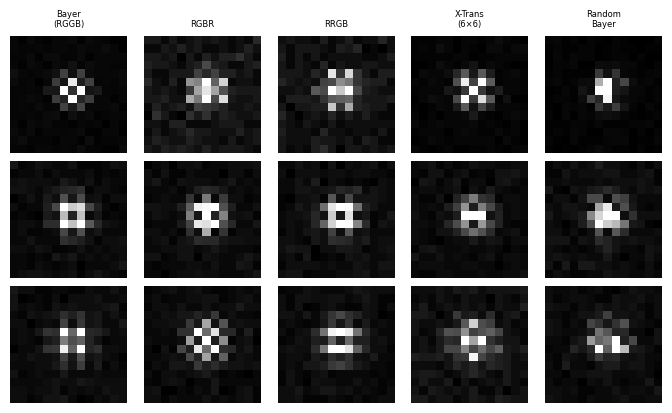

In [9]:
# ── PSF images: 3 dyes × 5 patterns ──────────────────────────────────────────
vis_image_size = 14
vis_pixel_size = 69
vis_NA         = 1.49
vis_background = 4
vis_n_photon   = 4000
vis_dyes       = ["ATTO 488", "ATTO 565", "ATTO 647N"]
vis_filters    = []

# One representative random patch for visualisation
rng_vis = np.random.default_rng(0)
mosaic_random_vis = sample_chip_patch(chip_pattern, vis_image_size, rng_vis)

pattern_mosaics = {
    "Bayer\n(RGGB)":   mosaic_bayer,
    "RGBR":            mosaic_rgbr,
    "RRGB":            mosaic_rrgb,
    "X-Trans\n(6×6)":  mosaic_xtrans,
    "Random\nBayer":   mosaic_random_vis,
}

R_eff, G_eff, B_eff, wavelength_vis = S_F.getpixelefficiency()
pixel_QYs_vis = np.vstack([B_eff, G_eff, R_eff])

x0_vis = (vis_image_size // 2) * vis_pixel_size
y0_vis = (vis_image_size // 2) * vis_pixel_size

n_patterns = len(pattern_mosaics)
n_dyes_vis = len(vis_dyes)
fig, axs = plt.subplots(
    nrows=n_dyes_vis, ncols=n_patterns,
    figsize=(6.69, 6.69 * n_dyes_vis / n_patterns),
    squeeze=False,
)

fs = plotter.config.font_size

for col, (pname, mosaic) in enumerate(pattern_mosaics.items()):
    masks_vis = M_F.get_masks(size_x=vis_image_size, size_y=vis_image_size, mosaic_unit=mosaic)
    cam_vis = {
        "gain":               np.full((vis_image_size, vis_image_size), np.median(gain)),
        "offset":             np.full((vis_image_size, vis_image_size), np.median(offset)),
        "variance":           np.full((vis_image_size, vis_image_size), np.median(variance)),
        "readnoise":          float(np.median(readnoise)),
        "rqe":                np.full((vis_image_size, vis_image_size), np.median(rqe)),
        "masks":              masks_vis,
        "pixel_QYs":          pixel_QYs_vis,
        "pixel_order":        ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    }
    for row, dye in enumerate(vis_dyes):
        ax = axs[row, col]
        aew, dpe = S_F.get_pixel_fractions_dye_and_filters(
            dye, vis_filters, wavelength_vis, pixel_QYs_vis
        )
        n_ph_vis  = {dye: np.full(1, vis_n_photon)}
        x0y0_vis  = {dye: np.zeros([1, 2, 1])}
        x0y0_vis[dye][:, :, :] = np.array([[y0_vis, x0_vis]]).T

        img, _, _ = MSF.gen_camera_image_stack(
            cam_vis, wavelength_vis,
            np.array(aew), np.array(dpe),
            n_ph_vis, x0y0_vis,
            background_photons=vis_background,
            smoothing_function=smoothing_function,
            NA=vis_NA, pixel_size=vis_pixel_size,
            return_normal_image=False,
        )
        plotter.image_plot(
            ax, img, colorbar=False,
            scalebarsize=200, pixelsize=vis_pixel_size, scalebarlabel="200 nm",
            scalebar_color="white", origin="lower",
        )
        if row == 0:
            ax.set_title(pname, fontsize=fs - 1)
        if col == 0:
            ax.set_ylabel(dye, fontsize=fs - 1)

folder_fig = save_folder_refactored
plt.savefig(os.path.join(folder_fig, "psf_images_new_patterns.svg"),
            dpi=300, format="svg")
plt.show()

In [10]:
# ── Simulation config for new patterns ────────────────────────────────────────
sim_image_size = 14
sim_pixel_size = 69
sim_NA         = 1.49
sim_dyes       = ["ATTO 488", "ATTO 565", "ATTO 647N"]
sim_filters    = []

n_photon_space_new = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)

config_new = SimulationConfig(
    n_bootstrap=100000,
    background_photons=5.0,
    NA=sim_NA,
    pixel_size=sim_pixel_size,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
)

R_sim, G_sim, B_sim, wavelength_sim = S_F.getpixelefficiency()
pixel_QYs_sim = np.vstack([B_sim, G_sim, R_sim])

# One random patch (seed 42) as the representative random-Bayer pattern
rng_sim = np.random.default_rng(42)
mosaic_random_sim = sample_chip_patch(chip_pattern, sim_image_size, rng_sim)

# Pattern registry: name → (mosaic_unit, starting_flag)
# Bayer is included so all 5 patterns share the same dye set (ATTO 488/565/647N).
sim_patterns = {
    "Bayer":        (mosaic_bayer,      "bayer_rggb_"),
    "RGBR":         (mosaic_rgbr,       "rgbr_"),
    "RRGB":         (mosaic_rrgb,       "rrgb_"),
    "X-Trans":      (mosaic_xtrans,     "xtrans_"),
    "Random_Bayer": (mosaic_random_sim, "random_bayer_s42_"),
}

print("Simulation patterns:")
for name, (mo, flag) in sim_patterns.items():
    n = mo.size
    print(f"  {name:16s}  flag={flag!r:25s}  "
          f"R={np.sum(mo=='R')/n:.3f}  G={np.sum(mo=='G')/n:.3f}  "
          f"B={np.sum(mo=='B')/n:.3f}")
print(f"\nDyes: {sim_dyes}")
print(f"Photon levels: {len(n_photon_space_new)}  "
      f"({n_photon_space_new[0]:.0f}–{n_photon_space_new[-1]:.0f})")
print(f"Save folder: {save_folder_refactored}")

Simulation patterns:
  Bayer             flag='bayer_rggb_'              R=0.250  G=0.500  B=0.250
  RGBR              flag='rgbr_'                    R=0.500  G=0.250  B=0.250
  RRGB              flag='rrgb_'                    R=0.500  G=0.250  B=0.250
  X-Trans           flag='xtrans_'                  R=0.222  G=0.556  B=0.222
  Random_Bayer      flag='random_bayer_s42_'        R=0.260  G=0.500  B=0.240

Dyes: ['ATTO 488', 'ATTO 565', 'ATTO 647N']
Photon levels: 200  (500–50000)
Save folder: /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_ArbitraryPixelPattern


In [ ]:
# ── Run simulations for all new patterns × dyes ───────────────────────────────
import time as _time

n_total_new = len(sim_patterns) * len(sim_dyes)
i_new = 0
t0_new = _time.time()

for pattern_name, (mosaic, flag) in sim_patterns.items():
    masks_sim = M_F.get_masks(
        size_x=sim_image_size, size_y=sim_image_size, mosaic_unit=mosaic
    )
    cam_sim = {
        "gain":                np.full((sim_image_size, sim_image_size), np.median(gain)),
        "offset":              np.full((sim_image_size, sim_image_size), np.median(offset)),
        "variance":            np.full((sim_image_size, sim_image_size), np.median(variance)),
        "readnoise":           float(np.median(readnoise)),
        "rqe":                 np.full((sim_image_size, sim_image_size), np.median(rqe)),
        "masks":               masks_sim,
        "pixel_QYs":           pixel_QYs_sim,
        "pixel_order":         ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    }
    for dye in sim_dyes:
        i_new += 1
        print(f"[{i_new:2d}/{n_total_new}]  {pattern_name:16s}  {dye}", end="  ")
        try:
            MSF.test_simulation_method(
                dye=dye,
                filters=sim_filters,
                wavelength=wavelength_sim,
                camera_parameters=cam_sim,
                save_folder=save_folder_refactored,
                n_photon_space=n_photon_space_new,
                smoothing_function=smoothing_function,
                strategy=FittingStrategy.STANDARD,
                starting_flag=flag,
                config=config_new,
                overwrite=True,
            )
            elapsed = (_time.time() - t0_new) / 60
            rate    = i_new / elapsed if elapsed > 0 else 0
            eta     = (n_total_new - i_new) / rate if rate > 0 else 0
            print(f"done  ({elapsed:.1f} min, ETA {eta:.1f} min)")
        except Exception as e:
            print(f"FAILED: {e}")

print(f"\nAll new-pattern simulations complete in {(_time.time()-t0_new)/60:.1f} min.")

In [ ]:
# ── Load results → build New_Patterns_XR ──────────────────────────────────────
# Dims: [pattern, dye, n_photons, metric]  metrics = ["sigma_xy", "sigma_colour"]
_all_files_new = os.listdir(save_folder_refactored)
_params_new    = ["sigma_xy", "sigma_colour"]
_pattern_names = list(sim_patterns.keys())

New_Patterns_XR = xr.DataArray(
    data=np.full(
        [len(_pattern_names), len(sim_dyes), len(n_photon_space_new), len(_params_new)],
        np.nan,
    ),
    coords={
        "pattern":   _pattern_names,
        "dye":       sim_dyes,
        "n_photons": n_photon_space_new,
        "metric":    _params_new,
    },
    dims=["pattern", "dye", "n_photons", "metric"],
)

for i_p, (pattern_name, (_, flag)) in enumerate(sim_patterns.items()):
    for i_d, dye in enumerate(sim_dyes):
        dye_str = dye.replace("/", "-")
        dye_files = [
            os.path.join(save_folder_refactored, f)
            for f in _all_files_new
            if f.startswith(flag) and dye_str in f
        ]
        raw_file  = [f for f in dye_files if "rawresults" in f]
        gt_file   = [f for f in dye_files if "groundtruth" in f]
        ip_file   = [f for f in dye_files if "input_parameters" in f]

        if not raw_file or not gt_file or not ip_file:
            print(f"Missing files for {pattern_name} / {dye}")
            continue

        gt    = pd.read_csv(gt_file[0])
        gt_px = np.vstack([gt["x0"].to_numpy() / sim_pixel_size,
                           gt["y0"].to_numpy() / sim_pixel_size]).T

        dye_BGR     = pd.read_csv(ip_file[0]).to_numpy()[0][-3:]
        colour_true = np.expand_dims(dye_BGR / dye_BGR.sum(), 0)

        df_raw = pd.read_hdf(raw_file[0])

        for k, _ in enumerate(n_photon_space_new):
            sub = df_raw[df_raw["photon_level"] == k]
            filt = ~(
                (sub["xc"] < 0) | (sub["yc"] < 0) |
                (sub["s_x"] < 0) | (sub["s_y"] < 0) |
                (sub["xc"] > sim_image_size) | (sub["yc"] > sim_image_size)
            )
            if filt.sum() < 5:
                continue
            ex = sub["xc"].to_numpy()[filt] - gt_px[filt, 0]
            ey = sub["yc"].to_numpy()[filt] - gt_px[filt, 1]
            New_Patterns_XR[i_p, i_d, k, 0] = (
                np.sqrt((np.nanstd(ex)**2 + np.nanstd(ey)**2) / 2) * sim_pixel_size
            )
            colour = np.vstack([
                sub["A_B"].to_numpy()[filt],
                sub["A_G"].to_numpy()[filt],
                sub["A_R"].to_numpy()[filt],
            ]).T
            New_Patterns_XR[i_p, i_d, k, 1] = float(np.nanstd(cdist(colour, colour_true)))

New_Patterns_XR.to_netcdf(
    os.path.join(save_folder_refactored, "New_Patterns_XR.nc")
)
print(f"Saved  shape={New_Patterns_XR.shape}  dims={list(New_Patterns_XR.dims)}")
n_valid = int(np.sum(~np.isnan(New_Patterns_XR.sel(metric="sigma_xy").values)))
print(f"{n_valid} / {New_Patterns_XR.sel(metric='sigma_xy').size} grid cells filled")

In [ ]:
# ── Comparison: σ_xy and σ_colour vs N_photons, all patterns ──────────────────
New_Patterns_XR = xr.load_dataarray(
    os.path.join(save_folder_refactored, "New_Patterns_XR.nc")
)

# Colour / style per pattern — Bayer is the solid black reference line
_pattern_styles = {
    "Bayer":        dict(color="black",    lw=1.5, ls="-",  zorder=5),
    "RGRB":         dict(color="#e6194b",  lw=1.2, ls="-"),
    "RRGB":         dict(color="#3cb44b",  lw=1.2, ls="-"),
    "X-Trans":      dict(color="#4363d8",  lw=1.2, ls="-"),
    "Random_Bayer": dict(color="#f58231",  lw=1.2, ls="--"),
}

fig, axs = plt.subplots(1, 2, figsize=(6.69, 3.1), squeeze=True)
fs = plotter.config.font_size

for ax, metric, ylabel in [
    (axs[0], "sigma_xy",     r"$\sigma_{xy}$ / nm"),
    (axs[1], "sigma_colour", r"$\sigma_{\rm colour}$"),
]:
    for pattern_name, style in _pattern_styles.items():
        y = np.nanmean(
            New_Patterns_XR.sel(pattern=pattern_name, metric=metric).values, axis=0
        )  # mean over dye axis
        ax.plot(n_photon_space_new, y,
                label=pattern_name.replace("_", " "), **style)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$N_{\rm photons}$", fontsize=fs)
    ax.set_ylabel(ylabel, fontsize=fs)
    ax.set_xlim([n_photon_space_new[0], n_photon_space_new[-1]])
    ax.tick_params(labelsize=fs - 1)
    ax.legend(loc="best", fontsize=fs - 2, framealpha=0.7)

fig.tight_layout(pad=0.4)
plt.savefig(
    os.path.join(save_folder_refactored, "new_patterns_precision_comparison.svg"),
    dpi=300, format="svg",
)
plt.show()